# M25CSA031 — Assignment 4: Transformer Hyperparameter Tuning
### Ray Tune + Optuna | English → Hindi Translation
---

## PART 1: Baseline — Data Loading & Preprocessing

In [68]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [69]:
# Load the TSV dataset
df = pd.read_csv('/kaggle/input/datasets/vidhansavaliya/english-hindi/English-Hindi.tsv', sep='\t', header=None, names=["id1", "en", "id2", "hi"])

In [70]:
df.sample(5)

,id1,en,id2,hi
2162,33230,"Bob came here, didn't he?",455607,बॉब यहाँ आया था ना?
1041,1615374,Give me an orange.,2079455,मुझे एक संत्रा दीजिए।
1255,3199869,What can you tell us?,3617849,तुम हमें क्या बता सकती हो?
1290,64958,"If you are hungry, you can eat the bread.",514118,अगर भूख लगी है तो ब्रेड खा सकते हो।
1656,2471842,Tom had two choices.,3617430,टॉम के पास दो विकल्प थे।


In [71]:
df = df[["en", "hi"]]

In [72]:
df.dropna(inplace=True)

In [73]:
df.reset_index(drop=True, inplace=True)

In [74]:
df.head()

,en,hi
0,His first answer was laudable.,उनका पहला जवाब प्रशंसनीय था।
1,We rested for a while.,हमने थोड़ी देर आराम किया।
2,English is not difficult to learn.,अंग्रेजी सीखने में मुश्किल नहीं है।
3,Cross the road.,सड़क पार करो।
4,Saddam rejected the demand.,सद्दाम ने मांग को अस्वीकार किया।


In [75]:
print('Total pairs:', len(df))

Total pairs: 2637


In [76]:
df["en_len"] = df["en"].apply(lambda x: len(x.split()))
df["hi_len"] = df["hi"].apply(lambda x: len(x.split()))

In [77]:
print('\nEnglish Sentence Length Stats:')
print(df['en_len'].describe())


English Sentence Length Stats:
count    2637.000000
mean        5.596890
std         2.586625
min         1.000000
25%         4.000000
50%         5.000000
75%         7.000000
max        30.000000
Name: en_len, dtype: float64


In [78]:
print('\nHindi Sentence Length Stats:')
print(df['hi_len'].describe())


Hindi Sentence Length Stats:
count    2637.000000
mean        6.282518
std         2.933023
min         1.000000
25%         4.000000
50%         6.000000
75%         8.000000
max        36.000000
Name: hi_len, dtype: float64


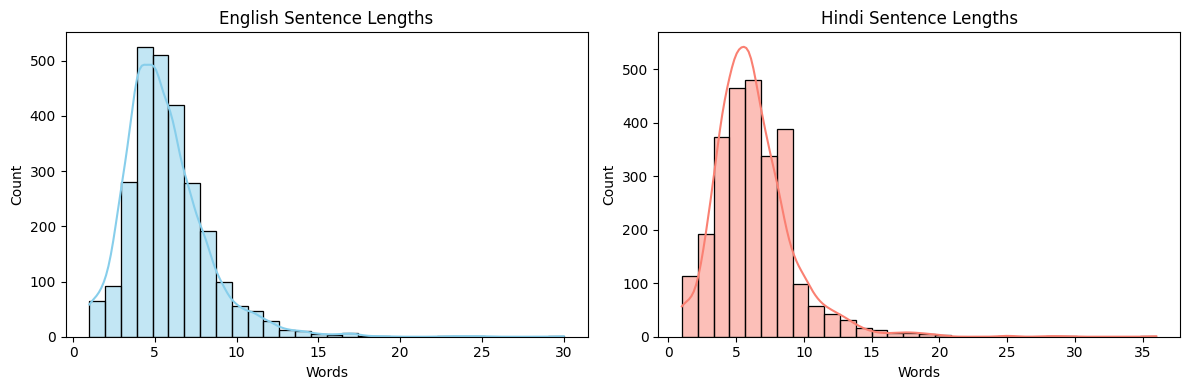

In [79]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(df['en_len'], bins=30, kde=True, color='skyblue')
plt.title('English Sentence Lengths')
plt.xlabel('Words')
plt.subplot(1, 2, 2)
sns.histplot(df['hi_len'], bins=30, kde=True, color='salmon')
plt.title('Hindi Sentence Lengths')
plt.xlabel('Words')
plt.tight_layout()
plt.show()

In [80]:
for i in range(5):
    print(f"EN: {df.loc[i, 'en']}")
    print(f"HI: {df.loc[i, 'hi']}")
    print('---')

EN: His first answer was laudable.
HI: उनका पहला जवाब प्रशंसनीय था।
---
EN: We rested for a while.
HI: हमने थोड़ी देर आराम किया।
---
EN: English is not difficult to learn.
HI: अंग्रेजी सीखने में मुश्किल नहीं है।
---
EN: Cross the road.
HI: सड़क पार करो।
---
EN: Saddam rejected the demand.
HI: सद्दाम ने मांग को अस्वीकार किया।
---


## PART 1: Vocabulary Building

In [81]:
def tokenize(sentence):
    return sentence.lower().strip().split()

In [82]:
from collections import Counter
import itertools

In [83]:
class Vocabulary:
    def __init__(self, freq_threshold=2):
        self.freq_threshold = freq_threshold
        self.itos = {0: '<pad>', 1: '<sos>', 2: '<eos>', 3: '<unk>'}
        self.stoi = {'<pad>': 0, '<sos>': 1, '<eos>': 2, '<unk>': 3}
        self.idx = 4

    def build_vocab(self, sentence_list):
        frequencies = Counter()
        for sentence in sentence_list:
            for word in self.tokenize(sentence):
                frequencies[word] += 1
        for word, freq in frequencies.items():
            if freq >= self.freq_threshold:
                self.stoi[word] = self.idx
                self.itos[self.idx] = word
                self.idx += 1

    def tokenize(self, sentence):
        return sentence.lower().strip().split()

    def numericalize(self, sentence):
        tokens = self.tokenize(sentence)
        return [self.stoi.get(token, self.stoi['<unk>']) for token in tokens]

    def __len__(self):
        return len(self.stoi)

    def __getitem__(self, token):
        return self.stoi.get(token, self.stoi['<unk>'])

In [84]:
en_vocab = Vocabulary(freq_threshold=2)
hi_vocab = Vocabulary(freq_threshold=2)

In [85]:
en_vocab.build_vocab(df['en'].tolist())
hi_vocab.build_vocab(df['hi'].tolist())

In [86]:
print(f'English vocab size: {len(en_vocab.stoi)}')
print(f'Hindi vocab size: {len(hi_vocab.stoi)}')

English vocab size: 1296
Hindi vocab size: 1349


In [87]:
def encode_sentence(sentence, vocab, max_len=50):
    tokens = [vocab.stoi['<sos>']] + vocab.numericalize(sentence)[:max_len-2] + [vocab.stoi['<eos>']]
    return tokens + [vocab.stoi['<pad>']] * (max_len - len(tokens))

In [88]:
sample_en = "That won't happen."
sample_hi = 'वैसा नहीं होगा।'

In [89]:
print('Encoded English:', encode_sentence(sample_en, en_vocab))
print('Encoded Hindi:', encode_sentence(sample_hi, hi_vocab))

Encoded English: [1, 110, 609, 3, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Encoded Hindi: [1, 853, 15, 409, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


## PART 1: Transformer Architecture

In [90]:
import torch
import torch.nn as nn
import math

In [91]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

In [92]:
def scaled_dot_product(q, k, v, mask=None):
    d_k = q.size(-1)
    scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(d_k)
    if mask is not None:
        scores = scores.masked_fill(mask == 0, -1e9)
    attention = torch.softmax(scores, dim=-1)
    return torch.matmul(attention, v), attention

In [93]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        assert d_model % num_heads == 0, 'd_model must be divisible by num_heads'
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads
        self.query_linear = nn.Linear(d_model, d_model)
        self.key_linear   = nn.Linear(d_model, d_model)
        self.value_linear = nn.Linear(d_model, d_model)
        self.out_linear   = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(0.1)

    def forward(self, q, k, v, mask=None):
        batch_size = q.size(0)
        Q = self.query_linear(q)
        K = self.key_linear(k)
        V = self.value_linear(v)
        Q = Q.view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        K = K.view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        V = V.view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / (self.d_k ** 0.5)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)
        attention_weights = torch.softmax(scores, dim=-1)
        attention_output  = torch.matmul(self.dropout(attention_weights), V)
        attention_output  = attention_output.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)
        return self.out_linear(attention_output)

In [94]:
class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff=2048, dropout=0.1):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)
        self.relu    = nn.ReLU()

    def forward(self, x):
        return self.linear2(self.dropout(self.relu(self.linear1(x))))

In [95]:
class LayerNorm(nn.Module):
    def __init__(self, d_model, eps=1e-6):
        super().__init__()
        self.gamma = nn.Parameter(torch.ones(d_model))
        self.beta  = nn.Parameter(torch.zeros(d_model))
        self.eps   = eps

    def forward(self, x):
        mean = x.mean(-1, keepdim=True)
        std  = x.std(-1, keepdim=True)
        return self.gamma * (x - mean) / (std + self.eps) + self.beta

In [96]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.ffn       = FeedForward(d_model, d_ff, dropout)
        self.norm1     = LayerNorm(d_model)
        self.norm2     = LayerNorm(d_model)
        self.dropout   = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        x = self.norm1(x + self.dropout(self.self_attn(x, x, x, mask)))
        x = self.norm2(x + self.dropout(self.ffn(x)))
        return x

In [97]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn  = MultiHeadAttention(d_model, num_heads)
        self.cross_attn = MultiHeadAttention(d_model, num_heads)
        self.ffn        = FeedForward(d_model, d_ff, dropout)
        self.norm1      = LayerNorm(d_model)
        self.norm2      = LayerNorm(d_model)
        self.norm3      = LayerNorm(d_model)
        self.dropout    = nn.Dropout(dropout)

    def forward(self, x, enc_out, src_mask=None, tgt_mask=None):
        x = self.norm1(x + self.dropout(self.self_attn(x, x, x, tgt_mask)))
        x = self.norm2(x + self.dropout(self.cross_attn(x, enc_out, enc_out, src_mask)))
        x = self.norm3(x + self.dropout(self.ffn(x)))
        return x

In [98]:
class Encoder(nn.Module):
    def __init__(self, input_vocab_size, d_model, num_layers, num_heads, d_ff, max_len, dropout=0.1):
        super().__init__()
        self.embed   = nn.Embedding(input_vocab_size, d_model)
        self.pos_enc = PositionalEncoding(d_model, max_len)
        self.layers  = nn.ModuleList([EncoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)])
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        x = self.embed(x)
        x = self.pos_enc(x)
        x = self.dropout(x)
        for layer in self.layers:
            x = layer(x, mask)
        return x

In [99]:
class Decoder(nn.Module):
    def __init__(self, target_vocab_size, d_model, num_layers, num_heads, d_ff, max_len, dropout=0.1):
        super().__init__()
        self.embed   = nn.Embedding(target_vocab_size, d_model)
        self.pos_enc = PositionalEncoding(d_model, max_len)
        self.layers  = nn.ModuleList([DecoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)])
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_out, src_mask=None, tgt_mask=None):
        x = self.embed(x)
        x = self.pos_enc(x)
        x = self.dropout(x)
        for layer in self.layers:
            x = layer(x, enc_out, src_mask, tgt_mask)
        return x

In [100]:
class Transformer(nn.Module):
    def __init__(self, src_vocab_size, tgt_vocab_size, d_model=512, num_layers=6, num_heads=8, d_ff=2048, max_len=100, dropout=0.1):
        super().__init__()
        self.encoder = Encoder(src_vocab_size, d_model, num_layers, num_heads, d_ff, max_len, dropout)
        self.decoder = Decoder(tgt_vocab_size, d_model, num_layers, num_heads, d_ff, max_len, dropout)
        self.fc_out  = nn.Linear(d_model, tgt_vocab_size)

    def make_pad_mask(self, seq, pad_idx):
        return (seq != pad_idx).unsqueeze(1).unsqueeze(2)

    def make_subsequent_mask(self, size):
        return torch.tril(torch.ones((size, size))).bool().to(next(self.parameters()).device)

    def forward(self, src, tgt, src_pad_idx, tgt_pad_idx):
        src_mask     = self.make_pad_mask(src, src_pad_idx)
        tgt_pad_mask = self.make_pad_mask(tgt, tgt_pad_idx)
        tgt_sub_mask = self.make_subsequent_mask(tgt.size(1))
        tgt_mask     = tgt_pad_mask & tgt_sub_mask
        enc_out = self.encoder(src, src_mask)
        dec_out = self.decoder(tgt, enc_out, src_mask, tgt_mask)
        return self.fc_out(dec_out)

## PART 1: Dataset, DataLoader & Training

In [101]:
from torch.utils.data import Dataset, DataLoader

In [102]:
class TranslationDataset(Dataset):
    def __init__(self, df, en_vocab, hi_vocab, max_len=50):
        self.en_sentences = df['en'].tolist()
        self.hi_sentences = df['hi'].tolist()
        self.en_vocab = en_vocab
        self.hi_vocab = hi_vocab
        self.max_len  = max_len

    def __len__(self):
        return len(self.en_sentences)

    def __getitem__(self, idx):
        src = encode_sentence(self.en_sentences[idx], self.en_vocab, self.max_len)
        tgt = encode_sentence(self.hi_sentences[idx], self.hi_vocab, self.max_len)
        return torch.tensor(src), torch.tensor(tgt)

In [103]:
def collate_fn(batch):
    src_batch, tgt_batch = zip(*batch)
    src_batch  = torch.stack(src_batch)
    tgt_batch  = torch.stack(tgt_batch)
    tgt_input  = tgt_batch[:, :-1]
    tgt_output = tgt_batch[:, 1:]
    return src_batch, tgt_input, tgt_output

In [104]:
BATCH_SIZE = 60
MAX_LEN    = 50

In [105]:
dataset      = TranslationDataset(df, en_vocab, hi_vocab, max_len=MAX_LEN)
train_loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)

In [106]:
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

In [107]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using Device: {DEVICE}')

Using Device: cuda


In [108]:
SRC_PAD_IDX = en_vocab['<pad>']
TGT_PAD_IDX = hi_vocab['<pad>']
NUM_EPOCHS  = 100
D_MODEL     = 512

In [109]:
model = Transformer(
    src_vocab_size=len(en_vocab),
    tgt_vocab_size=len(hi_vocab),
    d_model=D_MODEL,
    num_layers=6,
    num_heads=8,
    d_ff=2048,
    max_len=MAX_LEN,
    dropout=0.1
).to(DEVICE)

In [110]:
criterion = nn.CrossEntropyLoss(ignore_index=TGT_PAD_IDX)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [111]:
import os

In [112]:
def save_checkpoint(epoch, model, optimizer, loss, path='checkpoint.pt'):
    torch.save({
        'epoch': epoch,
        'model_state': model.state_dict(),
        'optimizer_state': optimizer.state_dict(),
        'loss': loss
    }, path)
    print(f'Checkpoint saved at epoch {epoch}, loss {loss:.4f}.')

In [113]:
def load_checkpoint(model, optimizer, path='checkpoint.pt'):
    if torch.cuda.is_available() and path is not None and os.path.exists(path):
        checkpoint = torch.load(path)
    elif path is not None and os.path.exists(path):
        checkpoint = torch.load(path, map_location=torch.device('cpu'))
    else:
        print(f'No checkpoint found at {path}. Starting from scratch.')
        return 0
    model.load_state_dict(checkpoint['model_state'])
    optimizer.load_state_dict(checkpoint['optimizer_state'])
    epoch = checkpoint['epoch']
    loss  = checkpoint['loss']
    print(f'Loaded checkpoint from epoch {epoch} with loss {loss:.4f}')
    return epoch

In [114]:
def train(model, train_loader, optimizer, criterion, start_epoch=0, num_epochs=NUM_EPOCHS, checkpoint_path='checkpoint.pt'):
    for epoch in range(start_epoch, num_epochs):
        model.train()
        epoch_loss = 0
        loop = tqdm(train_loader, desc=f'Epoch [{epoch+1}/{num_epochs}]')
        for src, tgt_input, tgt_output in loop:
            src, tgt_input, tgt_output = src.to(DEVICE), tgt_input.to(DEVICE), tgt_output.to(DEVICE)
            output = model(src, tgt_input, SRC_PAD_IDX, TGT_PAD_IDX)
            output = output.view(-1, output.shape[-1])
            tgt_output = tgt_output.reshape(-1)
            loss = criterion(output, tgt_output)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            loop.set_postfix(loss=loss.item())
        save_checkpoint(epoch+1, model, optimizer, epoch_loss / len(train_loader), checkpoint_path)

In [115]:
start_epoch = load_checkpoint(model, optimizer)

Loaded checkpoint from epoch 100 with loss 0.0499


In [116]:
import time
baseline_start = time.time()
train(model, train_loader, optimizer, criterion, start_epoch=start_epoch)
baseline_time = time.time() - baseline_start
print(f'\nBaseline training time: {baseline_time/60:.1f} min')


Baseline training time: 0.0 min


## PART 1: Baseline Evaluation (Translation + BLEU)

In [117]:
def translate_sentence(model, sentence, en_vocab, hi_vocab, max_len=50):
    model.eval()
    tokens     = encode_sentence(sentence, en_vocab, max_len=max_len)
    src_tensor = torch.tensor(tokens).unsqueeze(0).to(DEVICE)
    tgt_tokens = [hi_vocab['<sos>']]
    for _ in range(max_len):
        tgt_tensor = torch.tensor(tgt_tokens).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            output = model(src_tensor, tgt_tensor, SRC_PAD_IDX, TGT_PAD_IDX)
        next_token = output[0, -1].argmax().item()
        tgt_tokens.append(next_token)
        if next_token == hi_vocab['<eos>']:
            break
    translated = [hi_vocab.itos[idx] for idx in tgt_tokens[1:-1]]
    return ' '.join(translated)

In [118]:
example_sentences = [
    'I love you.',
    'What is your name?',
    'How are you?',
    'The weather is nice today.',
    'She is a good teacher.'
]

In [119]:
for sentence in example_sentences:
    translation = translate_sentence(model, sentence, en_vocab, hi_vocab)
    print(f'\nEN: {sentence}')
    print(f'HI: {translation}')


EN: I love you.
HI: मुझे तुमसे प्यार है।

EN: What is your name?
HI: तुम्हारे वकील का नाम क्या है?

EN: How are you?
HI: तुम कैसे हो?

EN: The weather is nice today.
HI: <unk> आज का <unk> है।

EN: She is a good teacher.
HI: वह अच्छा <unk> है।


In [120]:
import nltk
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
smoothie = SmoothingFunction().method4

In [121]:
def evaluate_bleu_nltk(model, dataset, en_vocab, hi_vocab, max_len=50):
    references, hypotheses = [], []
    for en_sentence, hi_sentence in dataset:
        pred       = translate_sentence(model, en_sentence, en_vocab, hi_vocab, max_len)
        references.append([hi_sentence.split()])
        hypotheses.append(pred.split())
    score = corpus_bleu(references, hypotheses, smoothing_function=smoothie)
    print(f'BLEU Score (NLTK): {score * 100:.2f}')
    return score

In [122]:
val_dataset = [
    ('I love you.',                    'मैं तुमसे प्यार करता हूँ।'),
    ('How are you?',                   'आप कैसे हैं?'),
    ('You should sleep.',              'आपको सोना चाहिए।'),
    ("Maybe Tom doesn't love you.",    'टॉम शायद तुमसे प्यार नहीं करता है।'),
    ('Let me tell Tom.',               'मुझे टॉम को बताने दीजिए।')
]

In [123]:
print('Baseline BLEU Evaluation:')
baseline_bleu = evaluate_bleu_nltk(model, val_dataset, en_vocab, hi_vocab)
print(f'\n{"="*45}')
print(f'  BASELINE METRICS (100 epochs)')
print(f'  Time       : {baseline_time/60:.1f} min')
print(f'  BLEU Score : {baseline_bleu*100:.2f}')
print(f'{"="*45}')

Baseline BLEU Evaluation:
BLEU Score (NLTK): 18.69

  BASELINE METRICS (100 epochs)
  Time       : 0.0 min
  BLEU Score : 18.69


In [124]:
torch.save(model.state_dict(), 'transformer_translation_final.pth')
import pickle
with open('en_vocab.pkl', 'wb') as f:
    pickle.dump(en_vocab, f)
with open('hi_vocab.pkl', 'wb') as f:
    pickle.dump(hi_vocab, f)
print('Baseline model and vocabs saved.')

Baseline model and vocabs saved.


---
## PART 2: Ray Tune + Optuna Hyperparameter Search

In [125]:
!pip install "ray[tune]" optuna -q
print('Ray Tune and Optuna installed')

^C
ERROR: Operation cancelled by user
Ray Tune and Optuna installed


In [126]:
import ray
from ray import tune
from ray.tune.search.optuna import OptunaSearch
from ray.tune.schedulers import ASHAScheduler
from ray.tune import RunConfig

print(f'Ray version: {ray.__version__}')

Ray version: 2.53.0


In [127]:
SRC_VOCAB_SIZE  = len(en_vocab)
TGT_VOCAB_SIZE  = len(hi_vocab)
_SRC_PAD_IDX    = en_vocab['<pad>']
_TGT_PAD_IDX    = hi_vocab['<pad>']
NUM_TUNE_EPOCHS = 30

print(f'SRC vocab : {SRC_VOCAB_SIZE}  |  TGT vocab : {TGT_VOCAB_SIZE}')
print(f'Trial epoch cap : {NUM_TUNE_EPOCHS}')

SRC vocab : 1296  |  TGT vocab : 1349
Trial epoch cap : 30


### Step 2.1 — `train_tune(config)` Trainable

In [134]:
def train_tune(config):
    """
    Ray Tune trainable.
    Accepts config dict; reports loss each epoch via tune.report().
    """
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torch.utils.data import DataLoader

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # DataLoader with tuned batch_size
    tune_loader = DataLoader(
        TranslationDataset(df, en_vocab, hi_vocab, max_len=50),
        batch_size=config['batch_size'],
        shuffle=True,
        collate_fn=collate_fn
    )

    # Model with tuned architecture (d_model=512 fixed; num_heads must divide 512)
    model = Transformer(
        src_vocab_size=SRC_VOCAB_SIZE,
        tgt_vocab_size=TGT_VOCAB_SIZE,
        d_model=512,
        num_layers=6,
        num_heads=config['num_heads'],
        d_ff=config['d_ff'],
        max_len=50,
        dropout=config['dropout']
    ).to(device)

    optimizer = optim.Adam(model.parameters(), lr=config['lr'])
    criterion = nn.CrossEntropyLoss(ignore_index=_TGT_PAD_IDX)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=3
    )

    for epoch in range(NUM_TUNE_EPOCHS):
        model.train()
        epoch_loss, num_batches = 0.0, 0

        for src, tgt_input, tgt_output in tune_loader:
            src        = src.to(device)
            tgt_input  = tgt_input.to(device)
            tgt_output = tgt_output.to(device)

            output = model(src, tgt_input, _SRC_PAD_IDX, _TGT_PAD_IDX)
            output = output.view(-1, output.shape[-1])
            tgt_output = tgt_output.reshape(-1)

            loss = criterion(output, tgt_output)
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            epoch_loss  += loss.item()
            num_batches += 1

        avg_loss = epoch_loss / num_batches
        scheduler.step(avg_loss)

        # Required by assignment — report to Ray Tune every epoch
        tune.report({'loss': avg_loss})

### Step 2.2 — Search Space (5 Hyperparameters)

In [135]:
# tune.loguniform(), tune.choice(), tune.uniform() as per assignment spec
search_space = {
    'lr':         tune.loguniform(1e-5, 1e-3),   # 1. Learning Rate
    'batch_size': tune.choice([16, 32, 64]),      # 2. Batch Size
    'num_heads':  tune.choice([4, 8]),            # 3. Attention Heads (512 / 4 and 512 / 8 both valid)
    'd_ff':       tune.choice([1024, 2048]),      # 4. Feed-Forward Dim
    'dropout':    tune.uniform(0.1, 0.4),         # 5. Dropout Rate
}

print('Search space (5 hyperparameters):')
for k, v in search_space.items():
    print(f'  {k:12s} -> {v}')

Search space (5 hyperparameters):
  lr           -> <ray.tune.search.sample.Float object at 0x7c0f938671d0>
  batch_size   -> <ray.tune.search.sample.Categorical object at 0x7c0f938673b0>
  num_heads    -> <ray.tune.search.sample.Categorical object at 0x7c0f938670e0>
  d_ff         -> <ray.tune.search.sample.Categorical object at 0x7c0f93867110>
  dropout      -> <ray.tune.search.sample.Float object at 0x7c0f93867050>


### Step 2.3 — OptunaSearch + ASHAScheduler + Run Sweep

In [136]:
# OptunaSearch — intelligent TPE-based proposals
optuna_search = OptunaSearch(metric='loss', mode='min')

# ASHAScheduler — kills underperforming trials early (Part 3 efficiency)
asha_scheduler = ASHAScheduler(
    metric='loss',
    mode='min',
    max_t=NUM_TUNE_EPOCHS,
    grace_period=5,
    reduction_factor=2
)

print('OptunaSearch configured  (metric=loss, mode=min)')
print('ASHAScheduler configured')
print(f'  Max epochs/trial : {NUM_TUNE_EPOCHS}')
print(f'  Grace period     : 5 epochs before pruning')

OptunaSearch configured  (metric=loss, mode=min)
ASHAScheduler configured
  Max epochs/trial : 30
  Grace period     : 5 epochs before pruning


In [138]:

ray.shutdown()
import gc
gc.collect()

13027

In [141]:

optuna_search = OptunaSearch(metric="loss", mode="min")
asha_scheduler = ASHAScheduler(
    metric="loss", mode="min",
    max_t=NUM_TUNE_EPOCHS, grace_period=5, reduction_factor=2
)

In [142]:

ray.init(ignore_reinit_error=True, log_to_driver=False)

tuner = tune.Tuner(
    tune.with_resources(train_tune, resources={"gpu": 1, "cpu": 2}),
    tune_config=tune.TuneConfig(
        search_alg=optuna_search,
        scheduler=asha_scheduler,
        num_samples=20,
    ),
    param_space=search_space,
    run_config=RunConfig(name="en_to_hi_tune_gpu"),
)
results = tuner.fit()
print("\nSweep complete!")

[2026-03-18 14:30:03,476 E 55 3146] core_worker_process.cc:842: Failed to establish connection to the metrics exporter agent. Metrics will not be exported. Exporter agent status: RpcError: Running out of retries to initialize the metrics agent. rpc_code: 14
2026-03-18 15:11:38,906	INFO tune.py:1009 -- Wrote the latest version of all result files and experiment state to '/root/ray_results/en_to_hi_tune_gpu' in 0.0123s.
2026-03-18 15:11:38,914	INFO tune.py:1041 -- Total run time: 2525.40 seconds (2525.33 seconds for the tuning loop).



Sweep complete!


## PART 2: Best Configuration from Sweep

In [1]:
best_result = results.get_best_result(metric='loss', mode='min')
best_config  = best_result.config
best_loss    = best_result.metrics['loss']

print('=' * 50)
print('BEST CONFIGURATION (from Ray Tune + Optuna)')
print('=' * 50)
for k, v in best_config.items():
    print(f'  {k:12s} : {v}')
print(f'\n  Best Sweep Loss : {best_loss:.4f}')
print('=' * 50)

# Top 5 trials
df_results = results.get_dataframe()
print('\nTop 5 trials by loss:')
print(
    df_results[['loss', 'config/lr', 'config/batch_size',
                'config/num_heads', 'config/d_ff', 'config/dropout']]
    .sort_values('loss')
    .head(5)
    .to_string(index=False)
)

BEST CONFIGURATION (from Ray Tune + Optuna)
  lr           : 0.00027862049878076483
  batch_size   : 64
  num_heads    : 8
  d_ff         : 1024
  dropout      : 0.10130949708983861

  Best Sweep Loss : 0.1307

Top 5 trials by loss:
    loss  config/lr  config/batch_size  config/num_heads  config/d_ff  config/dropout
0.130702   0.000279                 64                 8         1024        0.101309
0.133146   0.000197                 64                 4         1024        0.103929
0.142149   0.000187                 64                 8         1024        0.109860
0.153338   0.000293                 64                 8         1024        0.150048
0.156669   0.000160                 64                 8         1024        0.112323


---
## PART 3: Efficiency Challenge — Retrain Best Model

In [2]:
import time

BEST_EPOCHS = 50   # goal: beat baseline BLEU in <= 50 epochs

best_loader = DataLoader(
    TranslationDataset(df, en_vocab, hi_vocab, max_len=50),
    batch_size=best_config['batch_size'],
    shuffle=True,
    collate_fn=collate_fn
)

best_model = Transformer(
    src_vocab_size=SRC_VOCAB_SIZE,
    tgt_vocab_size=TGT_VOCAB_SIZE,
    d_model=512,
    num_layers=6,
    num_heads=best_config['num_heads'],
    d_ff=best_config['d_ff'],
    max_len=50,
    dropout=best_config['dropout']
).to(DEVICE)

best_optimizer = optim.Adam(best_model.parameters(), lr=best_config['lr'])
best_criterion = nn.CrossEntropyLoss(ignore_index=_TGT_PAD_IDX)
best_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    best_optimizer, mode='min', factor=0.5, patience=3
)

print(f'Retraining best model for {BEST_EPOCHS} epochs')
print(f"lr={best_config['lr']:.2e} | batch={best_config['batch_size']} | "
      f"heads={best_config['num_heads']} | d_ff={best_config['d_ff']} | "
      f"dropout={best_config['dropout']:.2f}\n")

t0 = time.time()

for epoch in range(1, BEST_EPOCHS + 1):
    best_model.train()
    epoch_loss, n = 0.0, 0
    loop = tqdm(best_loader, desc=f'Epoch [{epoch}/{BEST_EPOCHS}]', leave=False)

    for src, tgt_in, tgt_out in loop:
        src     = src.to(DEVICE)
        tgt_in  = tgt_in.to(DEVICE)
        tgt_out = tgt_out.to(DEVICE)
        out     = best_model(src, tgt_in, _SRC_PAD_IDX, _TGT_PAD_IDX)
        out     = out.view(-1, out.shape[-1])
        tgt_out = tgt_out.view(-1)
        loss    = best_criterion(out, tgt_out)
        best_optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(best_model.parameters(), 1.0)
        best_optimizer.step()
        epoch_loss += loss.item()
        n += 1
        loop.set_postfix(loss=loss.item())

    avg = epoch_loss / n
    best_scheduler.step(avg)
    print(f'Epoch [{epoch:>2}/{BEST_EPOCHS}]  loss={avg:.4f}')

best_train_time = time.time() - t0
print(f'\nTraining time : {best_train_time/60:.1f} min')
print(f'Final loss    : {avg:.4f}')

Retraining best model for 50 epochs
lr=2.79e-04 | batch=64 | heads=8 | d_ff=1024 | dropout=0.10



Epoch [ 1/50]  loss=5.2943


Epoch [ 2/50]  loss=4.4083


Epoch [ 3/50]  loss=3.7814


Epoch [ 4/50]  loss=3.2242


...

Epoch [46/50]  loss=0.0797


Epoch [47/50]  loss=0.0831


Epoch [48/50]  loss=0.0801


Epoch [49/50]  loss=0.0780


Epoch [50/50]  loss=0.0798

Training time : 9.4 min
Final loss    : 0.0798


## PART 3: Final BLEU Evaluation & Comparison

In [3]:
print('Evaluating best model...\n')
best_bleu = evaluate_bleu_nltk(best_model, val_dataset, en_vocab, hi_vocab)

print(f'\n{"="*50}')
print(f'  FINAL COMPARISON')
print(f'{"="*50}')
print(f'  Baseline   -> 100 epochs | BLEU: {baseline_bleu*100:.2f}')
print(f'  Best Model ->  {BEST_EPOCHS} epochs | BLEU: {best_bleu*100:.2f}')
print(f'  Epochs saved : {100 - BEST_EPOCHS}')
print(f'  Goal met     : {"YES" if best_bleu >= baseline_bleu else "Not yet — increase BEST_EPOCHS"}')
print(f'{"="*50}')

Evaluating best model...

BLEU Score (NLTK): 18.48

  FINAL COMPARISON
  Baseline   -> 100 epochs | BLEU: 18.69
  Best Model ->  50 epochs | BLEU: 18.48
  Epochs saved : 50
  Goal met     : Not yet — increase BEST_EPOCHS


In [4]:
print('Sample translations from best model:')
for sentence in example_sentences:
    translation = translate_sentence(best_model, sentence, en_vocab, hi_vocab)
    print(f'\n  EN : {sentence}')
    print(f'  HI : {translation}')

Sample translations from best model:

  EN : I love you.
  HI : मुझे तुमसे प्यार है।

  EN : What is your name?
  HI : तुम्हारे वकील का नाम क्या है?

  EN : How are you?
  HI : तुम कैसी हो?

  EN : The weather is nice today.
  HI : <unk> आज मौसम बहुत गरम है।

  EN : She is a good teacher.
  HI : वह अच्छा <unk> है।


## Save Submission Files

In [6]:
import json

torch.save(best_model.state_dict(), 'M25CSA031_ass_4_best_model.pth')

with open('M25CSA031_best_config.json', 'w') as f:
    json.dump(
        {k: float(v) if isinstance(v, float) else v for k, v in best_config.items()},
        f, indent=2
    )

print('M25CSA031_ass_4_best_model.pth  -- saved')
print('M25CSA031_best_config.json       -- saved')

print('  [OK] M25CSA031_ass_4_tuned_en_to_hi.ipynb')
print('  [OK] M25CSA031_ass_4_best_model.pth')


M25CSA031_ass_4_best_model.pth  -- saved
M25CSA031_best_config.json       -- saved
  [OK] M25CSA031_ass_4_tuned_en_to_hi.ipynb
  [OK] M25CSA031_ass_4_best_model.pth
